# Image processing notebook: From overlap corrected to transmission 

### 00 - exp 1XX acquisition 00

##  Initial settings

### Import libraries
Import all the required libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
%matplotlib inline

### Select directories
Select the source directory. This directory is where the images **after** the overlap correction were saved.
Select the destination directory. Here is where the transmission images are going to be saved.

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\01_Overlap_corrected\exp102"

In [3]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\02_Transmission_results\exp102"

### Check folders to process

In [4]:
stack_dict = prep_stack_dict(src_dir)
for key in stack_dict.keys():
    print(key)

000_ob_00
000_temp_00_p20_ob
001_ref_00
001_temp_00_p20_batch01
002_temp_00_p20_batch02
003_temp_00_p20_batch03
004_temp_01_p10_ob
005_temp_01_p10_batch01
006_temp_01_p10_batch02
007_temp_01_p10_batch03
008_temp_02_p0_ob
009_temp_02_p0_batch01
010_temp_02_p0_batch02
011_temp_02_p0_batch03
012_temp_03_m10_ob
013_temp_03_m10_batch01
014_temp_03_m10_batch02
015_temp_03_m10_batch03
016_temp_04_m23_ob
017_temp_04_m23_batch01
018_temp_04_m23_batch02
019_temp_04_m23_batch03
020_temp_05_m15_ob
021_temp_05_m15_batch01
022_temp_05_m15_batch02
023_temp_05_m15_batch03
024_temp_06_m5_ob
025_temp_06_m5_batch01
026_temp_06_m5_batch02
027_temp_06_m5_batch03
028_temp_07_p5_ob
029_temp_07_p5_batch01
030_temp_07_p5_batch02
031_temp_07_p5_batch03
032_temp_08_p17_ob
033_temp_08_p17_batch01
034_temp_08_p17_batch02
035_temp_08_p17_batch03
036_temp_09_p30_ob
037_temp_09_p30_batch01
038_temp_09_p30_batch02
039_temp_09_p30_batch03
040_temp_10_p40_ob
041_temp_10_p40_batch01
042_temp_10_p40_batch02
043_temp_10_p4

In [5]:
proc_folder1 = [key for key in stack_dict.keys() if 'batch01' in key]
proc_folder2 = [key for key in stack_dict.keys() if 'batch02' in key]
proc_folder3 = [key for key in stack_dict.keys() if 'batch03' in key]
ref_folder = ['001_ref_00']

**Slicing the folders because the memory space does not allow to work with the full batch**

In [6]:
proc_folder1_1 = proc_folder1 [0:10]
proc_folder1_2 = proc_folder1 [10:17]
#proc_folder1_3 = proc_folder1 [8:12]
#proc_folder1_4 = proc_folder1 [12:17]

proc_folder2_1 = proc_folder2 [0:10]
proc_folder2_2 = proc_folder2 [10:16]
#proc_folder2_3 = proc_folder2 [8:12]
#proc_folder2_4 = proc_folder2 [12:16]

proc_folder3_1 = proc_folder3 [0:10]
proc_folder3_2 = proc_folder3 [10:16]
#proc_folder3_3 = proc_folder3 [8:12]
#proc_folder3_4 = proc_folder3 [12:16]

## Process the reference folder (if not done before)
Or in case it is not previously saved.

In case the parameters and ref_dict are stored in the global variables, you can load them with : `%store -r "name given"`

It is **important** to not process the images fully before having played with them to find the right parameters (there is a notebook called playgound todo this)

In [7]:
#%store -r exp_param
#ref_dir =  r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\02_Transmission_results\exp102"
#ref_dict = read_saved_dict (ref_dir, proc_folder = ['001_ref_00'])

### Continue here if ref images are not done
if the ref images were done (with the same processing intended) then continue to section 3

## filterrsd

**gauss:**fgfgfgfg

meadiuMN

fgfgfg

efdfdf:

In [ ]:
seq=[g,m,ws]
apply filtrds_to_dict(apply)

In [8]:
ref_param = {}
nca_ref = [388, 10, 59, 488]

add_to_dict(ref_param, ['threshold', 'nca', 'ws_filter_size'], [0, nca_ref, 3])

In [9]:
ref_seq =  [stack_averaging,
            scrubbing_correction_dict,
            ws_filter,
            outlier_removal,
            SBKG_correction_dict]

In [10]:
proc_folder = ref_folder
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_ref.fits')
add_to_dict(ref_param,['BB_mask'], [BB_mask])

ref_dict = full_processing (src_dir, dst_dir, proc_folder = ref_folder, sequence = ref_seq, 
                 proc_parameters = ref_param, img_name = 'intensity', save = True)

Reading Images: 100%|████████████████████████████| 3/3 [00:19<00:00,  6.61s/it]


Experiment 001_ref_00 in process...


Processing SBKG Correction: 100%|████████████████| 1/1 [00:40<00:00, 40.04s/it]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:20<00:00, 20.95s/it]


Total time: 710s


## Gettinging an NCA

In [11]:
test_folder01 = ['001_temp_00_p20_batch01']
test_folder02 = ['002_temp_00_p20_batch02']
test_folder03 = ['003_temp_00_p20_batch03']

img_dict01, _ = testing_mode_step (src_dir, proc_folder = test_folder01, keep_acq_numb = 1)
img_dict02, _ = testing_mode_step (src_dir, proc_folder = test_folder02, keep_acq_numb = 1)
img_dict03, _ = testing_mode_step (src_dir, proc_folder = test_folder03, keep_acq_numb = 1)

Reading Images: 100%|████████████████████████████| 3/3 [00:01<00:00,  1.79it/s]


In [12]:
img_batch01 = avg_frames_dict (img_dict01[test_folder01[0]], output_type = 'img')
img_batch02 = avg_frames_dict (img_dict02[test_folder02[0]], output_type = 'img')
img_batch03 = avg_frames_dict (img_dict03[test_folder03[0]], output_type = 'img')

In [13]:
# %load select_rois(img_batch01, list_rois = ['nca_01'])
nca_01 = [388, 10, 59, 488]

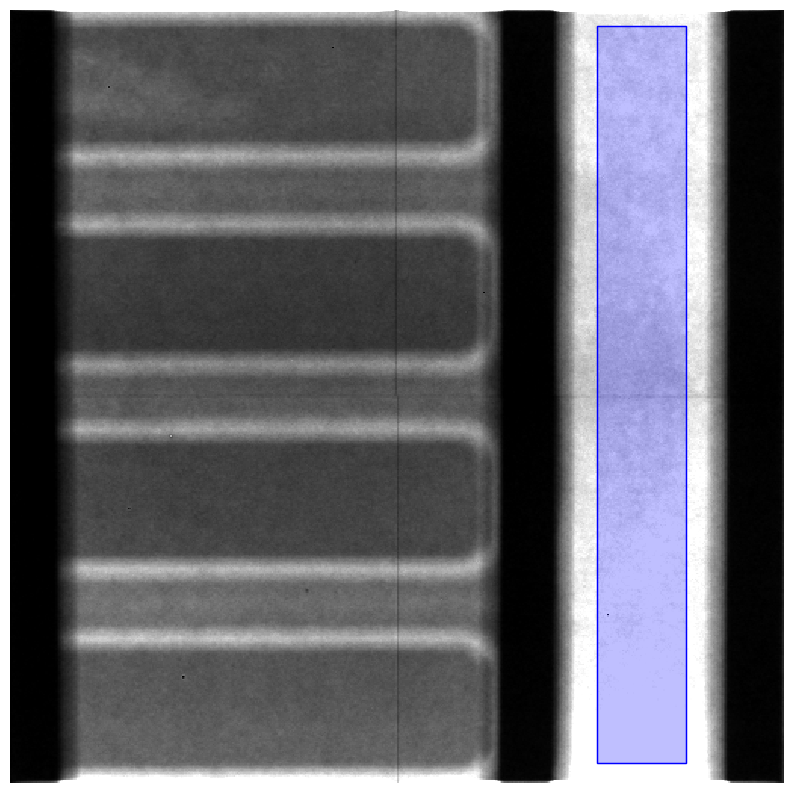

In [14]:
show_img(img_batch01[0], dr = [(nca_01, 'blue')], cmap='gray')

In [15]:
# %load select_rois(img_batch02, list_rois = ['nca_02'])
nca_02 = [390, 10, 59, 488]

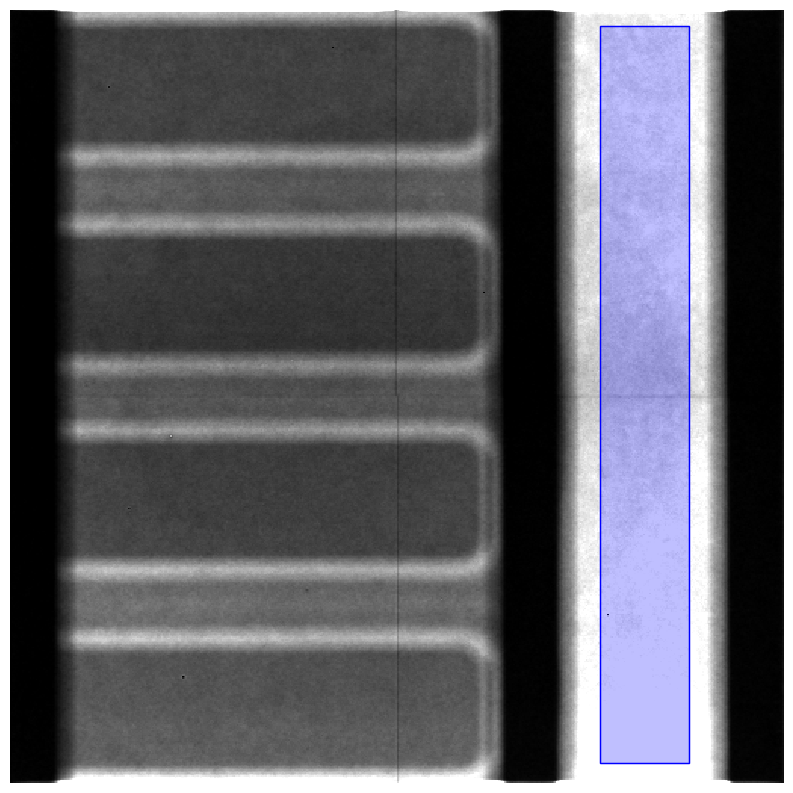

In [16]:
show_img(img_batch02[0], dr = [(nca_02, 'blue')], cmap='gray')

In [17]:
# %load select_rois(img_batch03, list_rois = ['nca_03'])
nca_03 = [390, 10, 59, 488]

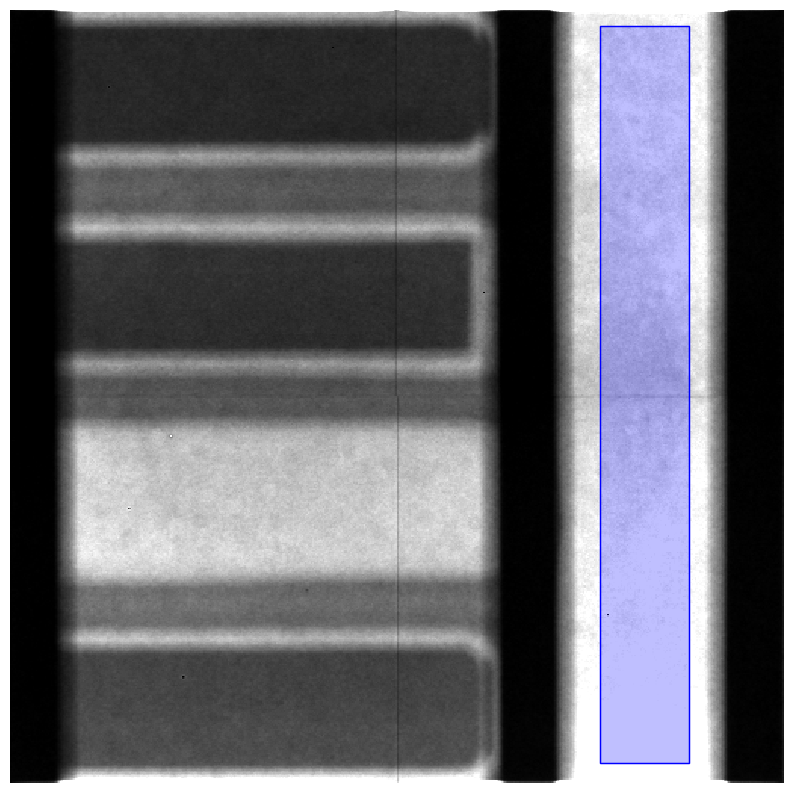

In [18]:
show_img(img_batch03[0], dr = [(nca_03, 'blue')], cmap='gray')

## Base parameters and Sequence

In [19]:
exp_param = {}

add_to_dict(exp_param, ['threshold', 'use_ref', 'ref_dict', 'ws_filter_size'], [0, True, ref_dict, 3])

In [20]:
exp_seq =  [stack_averaging,
            scrubbing_correction_dict,
            ws_filter,
            outlier_removal,
            SBKG_correction_dict,
            intensity_correction_dict,
            referencing_dict]

## Exp102 Processing

### Processing Batch 01

In [21]:
proc_folder = proc_folder1_1
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_batch01.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca_01])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|██████████████████████████| 21/21 [01:51<00:00,  5.30s/it]


Experiment 001_temp_00_p20_batch01 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.31it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.03s/it]


...

Experiment 037_temp_09_p30_batch01 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.30it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.48s/it]


Total time: 4170s


In [22]:
proc_folder = proc_folder1_2
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_batch01.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca_01])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|██████████████████████████| 14/14 [01:17<00:00,  5.51s/it]


Experiment 041_temp_10_p40_batch01 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.27it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.41s/it]


...

Experiment 065_temp_16_m23_batch01 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.30it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.62s/it]


Total time: 2825s


### Processing Batch 02

In [23]:
proc_folder = proc_folder2_1
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_batch02.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca_02])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|██████████████████████████| 21/21 [02:52<00:00,  8.21s/it]


Experiment 002_temp_00_p20_batch02 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.29it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.64s/it]


...

Experiment 038_temp_09_p30_batch02 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.30it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.66s/it]


Total time: 4472s


In [24]:
proc_folder = proc_folder2_2
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_batch02.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca_02])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|██████████████████████████| 13/13 [01:44<00:00,  8.07s/it]


Experiment 042_temp_10_p40_batch02 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.31it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.71s/it]


...

Experiment 062_temp_15_m15_batch02 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.09it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.05s/it]


Total time: 2563s


### Processing Batch 03

In [25]:
proc_folder = proc_folder3_1
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_batch03.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca_03])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|██████████████████████████| 21/21 [02:52<00:00,  8.22s/it]


Experiment 003_temp_00_p20_batch03 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.27it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.76s/it]


...

Experiment 039_temp_09_p30_batch03 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.27it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.76s/it]


Total time: 4377s


In [26]:
proc_folder = proc_folder3_2
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_batch03.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca_03])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|██████████████████████████| 13/13 [01:42<00:00,  7.87s/it]


Experiment 043_temp_10_p40_batch03 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.29it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.38s/it]


...

Experiment 063_temp_15_m15_batch03 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.29it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.66s/it]


Total time: 2573s
